## Project: Crop Price Prediction using LSTM

This notebook demonstrates how to build and train an LSTM model to predict crop prices based on historical data. We will cover data loading, preprocessing, model definition, training, evaluation, and saving the models.

### 1. Setup and Library Imports

First, we import all necessary libraries for data manipulation, numerical operations, plotting, and deep learning. We also suppress warnings for cleaner output.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


### 2. Data Loading

We'll upload a CSV file containing historical crop price data from our local machine to the Colab environment and load it into a pandas DataFrame. This cell will prompt you to select the `Karnataka_Processed.csv` file.

In [2]:
from google.colab import files
import io

print("Upload 'Karnataka_Processed.csv'")
uploaded = files.upload()

file_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"✅ Loaded: {df.shape}")
df.head()

Upload 'Karnataka_Processed.csv'


Saving Karnataka_Processed.csv to Karnataka_Processed.csv
✅ Loaded: (12774, 10)


,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Karnataka,bangalore,Ramanagara,Tomato,Tomato,FAQ,2000,2800,2500,6/06/2023
1,Karnataka,bangalore,Doddaballa Pur,Onion,Onion,FAQ,1400,2000,1700,6/06/2023
2,Karnataka,bangalore,Bangalore,Onion,Bangalore-Samall,FAQ,300,600,500,6/06/2023
3,Karnataka,bangalore,Doddaballa Pur,Tomato,Tomato,FAQ,1000,1600,1300,6/06/2023
4,Karnataka,bellary,Hospet,Tomato,Tomato,FAQ,700,1000,800,6/06/2023


### 3. Initial Data Exploration

Before proceeding, it's good practice to get an overview of the dataset. This includes checking its shape (rows, columns), column names, and the distribution of categorical features like 'Commodity'.

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nCrops:")
print(df['Commodity'].value_counts())

Shape: (12774, 10)

Columns:
Index(['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety',
       'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Price Date'],
      dtype='object')

Crops:
Commodity
Onion     6346
Potato    5190
Tomato    1238
Name: count, dtype: int64


### 4. Data Preprocessing: Date Conversion

The 'Price Date' column is currently a string. For time series analysis, it needs to be converted into datetime objects. We specify the format to ensure correct parsing.

In [5]:
df['Price Date'] = pd.to_datetime(df['Price Date'], format='%d/%m/%Y')
print("✅ Date converted")

✅ Date converted


### 5. Define Hyperparameters

Here, we define a crucial hyperparameter `LOOKBACK`. This value determines the number of previous time steps (days) the LSTM model will consider when making a prediction for the next day.

In [6]:
LOOKBACK = 30
print(f"Lookback Window: {LOOKBACK} days")

Lookback Window: 30 days


### 6. Data Preparation Function for LSTM

This function (`prepare_lstm_data`) is designed to process the raw DataFrame for a specific crop into a format suitable for LSTM. It performs the following steps:
- Filters data for the target crop.
- Groups by date and calculates the mean modal price.
- Resamples to daily frequency and handles missing dates.
- Scales the prices using `MinMaxScaler`.
- Creates sequences of `LOOKBACK` days as features (`X`) and the next day's price as the target (`y`).
- Splits the data into training and testing sets.

In [7]:
from sklearn.preprocessing import MinMaxScaler

def prepare_lstm_data(df, crop_name):

    crop_df = df[df['Commodity'] == crop_name].copy()

    crop_df = crop_df.groupby('Price Date')['Modal_Price'].mean().reset_index()
    crop_df = crop_df.sort_values('Price Date')

    crop_df = crop_df.set_index('Price Date')
    crop_df = crop_df.resample('D').mean()
    crop_df = crop_df.ffill().bfill()
    crop_df = crop_df.reset_index()

    prices = crop_df['Modal_Price'].values.reshape(-1,1)

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(prices)

    X = []
    y = []

    for i in range(LOOKBACK, len(scaled)):
        X.append(scaled[i-LOOKBACK:i,0])
        y.append(scaled[i,0])

    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], 1))

    split = int(len(X)*0.8)

    X_train = X[:split]
    X_test = X[split:]
    y_train = y[:split]
    y_test = y[split:]

    return X_train, X_test, y_train, y_test, scaler

### 7. Import TensorFlow Modules

We import the necessary components from Keras, a high-level API for building and training deep learning models, particularly for defining sequential models, LSTM layers, dense layers, dropout for regularization, and early stopping callbacks.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("✅ TensorFlow imported")

✅ TensorFlow imported


### 8. Build LSTM Model Function

This function (`build_lstm_model`) defines the architecture of our Long Short-Term Memory (LSTM) neural network. It consists of multiple LSTM layers, dropout layers to prevent overfitting, and a final dense layer to output the predicted price. The model is compiled with the Adam optimizer and Mean Squared Error (MSE) loss.

In [9]:
def build_lstm_model():

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
        Dropout(0.2),

        LSTM(32),
        Dropout(0.2),

        Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

print("✅ LSTM model ready")

✅ LSTM model ready


### 9. Prepare Data for a Single Crop (e.g., Onion)

As an initial test and demonstration, we prepare the data specifically for 'Onion' using the `prepare_lstm_data` function. This provides us with the scaled training and testing datasets ready for model training.

In [10]:
X_train, X_test, y_train, y_test, scaler = prepare_lstm_data(df, 'Onion')

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (565, 30, 1)
Test Shape : (142, 30, 1)


### 10. Train LSTM Model for Onion

Here, we train the `build_lstm_model` on the prepared 'Onion' data. We include an `EarlyStopping` callback to monitor validation loss and stop training if the model performance on the validation set doesn't improve for a certain number of epochs, thus preventing overfitting and saving computational resources.

In [11]:
model = build_lstm_model()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0183 - val_loss: 0.0055
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0084 - val_loss: 0.0025
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0076 - val_loss: 0.0028
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0070 - val_loss: 0.0049
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0067 - val_loss: 0.0043
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0068 - val_loss: 0.0034
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0070 - val_loss: 0.0036
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0068 - val_loss: 0.0034
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0072 - val_loss: 0.0022
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0067 - val_loss: 0.0031
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0066 - val_loss: 0.0020
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step

### 11. Evaluate Onion Price Prediction Model

After training, we evaluate the model's performance on the test set. We make predictions, inverse-transform them to the original price scale, and then calculate key metrics such as Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²) to quantify prediction accuracy.

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predict
y_pred_scaled = model.predict(X_test, verbose=0)

# Convert back to original prices
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrics
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

RMSE : 431.47
MAE  : 276.66
R²   : 0.7348


### 12. Visualize Onion Price Predictions

This cell generates a plot that visually compares the actual (true) prices of Onions with the prices predicted by our LSTM model on the test dataset. This helps to understand how closely the model's predictions align with reality.

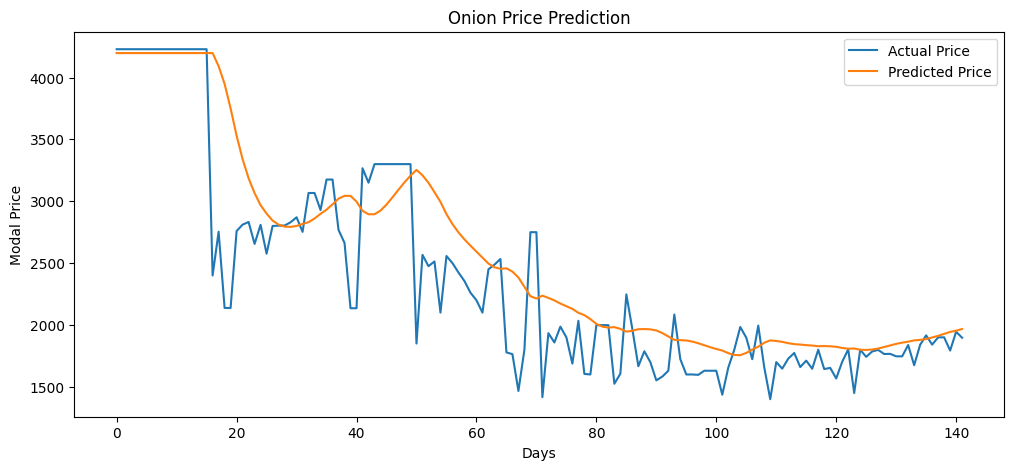

In [13]:
plt.figure(figsize=(12,5))

plt.plot(y_actual, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')

plt.title('Onion Price Prediction')
plt.xlabel('Days')
plt.ylabel('Modal Price')
plt.legend()

plt.show()

### 13. Batch Training and Evaluation for Multiple Crops

To apply our model to different crops, this section iterates through a list of `TARGET_CROPS` ('Tomato', 'Onion', 'Potato'). For each crop, it prepares the data, builds and trains a new LSTM model, evaluates its performance, and stores the metrics, the trained model, and its corresponding scaler in dictionaries.

In [14]:
TARGET_CROPS = ['Tomato', 'Onion', 'Potato']

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}
models = {}
scalers = {}

for crop in TARGET_CROPS:

    print(f"\n🌱 Training {crop}...")

    X_train, X_test, y_train, y_test, scaler = prepare_lstm_data(df, crop)

    model = build_lstm_model()

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=16,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred = scaler.inverse_transform(model.predict(X_test, verbose=0))
    y_actual = scaler.inverse_transform(y_test.reshape(-1,1))

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)

    results[crop] = [rmse, mae, r2]
    models[crop] = model
    scalers[crop] = scaler

    print(f"✅ RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f}")


🌱 Training Tomato...
✅ RMSE: 347.58 | MAE: 250.61 | R²: 0.1717

🌱 Training Onion...


✅ RMSE: 443.42 | MAE: 289.20 | R²: 0.7199

🌱 Training Potato...


✅ RMSE: 454.44 | MAE: 316.25 | R²: -0.0457


### 14. Display Summary of Model Performance

This cell organizes the evaluation metrics (RMSE, MAE, R²) for all `TARGET_CROPS` into a clear pandas DataFrame. This allows for an easy comparison of how well the LSTM models performed for each individual crop.

In [15]:
results_df = pd.DataFrame(
    results,
    index=['RMSE', 'MAE', 'R²']
).T

results_df

,RMSE,MAE,R²
Tomato,347.575845,250.614116,0.171742
Onion,443.415157,289.204699,0.719903
Potato,454.435928,316.245783,-0.045688


### 15. Save Trained Models and Scalers

To ensure reproducibility and enable future deployment, this section saves each trained LSTM model (as `.h5` files) and its corresponding `MinMaxScaler` (as `.pkl` files) to disk. This allows us to load and use these artifacts without needing to retrain the models.

In [16]:
import joblib

# Save all models and scalers
for crop in TARGET_CROPS:
    model_path = f'{crop.lower()}_model.h5'
    scaler_path = f'{crop.lower()}_scaler.pkl'

    models[crop].save(model_path)
    joblib.dump(scalers[crop], scaler_path)

    print(f"✅ Saved: {model_path} + {scaler_path}")

print("\n🎉 All models saved!")

✅ Saved: tomato_model.h5 + tomato_scaler.pkl
✅ Saved: onion_model.h5 + onion_scaler.pkl
✅ Saved: potato_model.h5 + potato_scaler.pkl

🎉 All models saved!


### 16. Download Saved Models and Scalers

This cell facilitates the download of all saved model and scaler files from the Google Colab environment to your local machine. This is important for deploying the models or for further analysis outside of Colab.

In [17]:
from google.colab import files

for crop in TARGET_CROPS:
    files.download(f'{crop.lower()}_model.h5')
    files.download(f'{crop.lower()}_scaler.pkl')

print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
